In [1]:
import sys
import os
sys.path.append(os.path.abspath(os.path.join(os.path.dirname('__file__'), '/home/kduplat/Documents/Data/Pscript2/Fct_scripts')))
from Tools import *

color_list = ['#0072b2', '#009e73', '#e69f00', '#d55e00','#f0e442',
              '#cc79a7', '#56b4e9', '#000000']

import cv2
from matplotlib.path import Path
from skimage.filters import threshold_multiotsu, threshold_otsu
from skimage import filters, measure
from scipy.ndimage.morphology import binary_closing
from scipy.ndimage import label

/tmp/ipykernel_764817/1055253456.py:13: DeprecationWarning: Please use `binary_closing` from the `scipy.ndimage` namespace, the `scipy.ndimage.morphology` namespace is deprecated.
  from scipy.ndimage.morphology import binary_closing


In [2]:
def class_contrast(image, thresholds):
    regions = np.digitize(image, bins=thresholds)
    means = [np.mean(image[regions == i]) for i in range(len(thresholds) + 1)]
    contrast = np.std(means)  # Dispersion des moyennes
    return contrast

def otsu_criterion(image, thresholds):
    """
    Calcule la variance intra-classe totale après seuillage multi-Otsu.
    Plus cette valeur est faible, meilleure est la séparation des classes.
    """
    regions = np.digitize(image, bins=thresholds)
    total_variance = 0
    
    for i in range(len(thresholds) + 1):
        mask = regions == i
        if np.any(mask):
            variance = np.var(image[mask])
            total_variance += variance
    
    return total_variance


from matplotlib.path import Path
def otsu_detection(nbclasse, image, m_size, sigma_X, sigma_Y, mode_switch, min_nbclass = 2):
    max_interclasse = 0
    min_intraclasse = 1e12
    max_nbclasse = 0
    
    """ blurred_image = cv2.GaussianBlur(image, (m_size, m_size), sigmaX = sigma_X, sigmaY = sigma_Y) """
    blurred_image  = cv2.medianBlur(image, 5)
    
    #Find the best number of classes
    for n in range(min_nbclass, nbclasse + 1):
        thresholds = threshold_multiotsu(blurred_image[image!=0], classes = n)
        if mode_switch == 0:
            contrast = class_contrast(image, thresholds)
            if contrast > max_interclasse:
                max_interclasse = contrast
                max_nbclasse = n
                
        elif mode_switch == 1:
            intra_std = otsu_criterion(image, thresholds)
            if intra_std < min_intraclasse:
                min_intraclasse = intra_std
                max_nbclasse = n
        else:
            raise ValueError("otsu_detection mode_switch must be 0 or 1")
    # max_nbclasse = 5
    return cluster_detection(blurred_image, max_nbclasse)

def contours_to_label_fct(labeled_image, contours, num_features):
    L1 = labeled_image.shape[0]
    L2 = labeled_image.shape[1]
    ##########External contour##########
    contour_to_label = []
    for j, contour in enumerate(contours):  
        external_path = Path(contour)
        for k in range(1,num_features + 1):
            patch = np.argwhere(labeled_image == k)
            inside = external_path.contains_points(patch)
            if np.any(inside): #Au moins un élément dans être contenu dans le contour
                contour_to_label.append([j, k])
                # ax.plot(contour[:, 1], contour[:, 0], linewidth=2, color="red", alpha=1)
                break
        else: 
            contour_to_label.append([j, -1]) #Si aucun élément n'est contenu dans le contour, c'est un contour interieur    
            # ax.plot(contour[:, 1], contour[:, 0], linewidth=2, color="blue", alpha=1)  

    ##########Internal contour##########
    contour_to_label = np.array(contour_to_label)
    mask = contour_to_label[:,1] == -1

    for _, int_id_contour in enumerate(contour_to_label[mask][:,0]):
        for _, (id_contour, idpatch) in enumerate(contour_to_label[~mask]):
            external_path = Path(contours[id_contour])
            inside = external_path.contains_points(contours[int_id_contour])
            if np.any(inside): #Au moins un élément dans être contenu dans le contour
                contour_to_label[int_id_contour,1] = idpatch 
                # ax.plot(contours[int_id_contour][:, 1], contours[int_id_contour][:, 0], linewidth=2, color="green", alpha=1)
                break
        else:
            for point in contours[int_id_contour]:
                y, x = np.floor(point).astype(int)

                neighbors = [(y+1, x), (y-1, x), (y, x+1), (y, x-1)]
                for y_neighbor, x_neighbor in neighbors: 
                    if 0 <= x_neighbor < L1 and 0 <= y_neighbor < L2:
                        label_val = labeled_image[y_neighbor, x_neighbor]
                        if label_val:
                            contour_to_label[int_id_contour, 1] = label_val
                            break

                    
        if contour_to_label[int_id_contour,1] == -1:
            print("A contour is not linked to a cluster, id_contour = {}".format(int_id_contour))
        """     ax.plot(contours[int_id_contour][:, 1], contours[int_id_contour][:, 0], linewidth=3, color="orange", alpha=1)
        else :
            ax.plot(contours[int_id_contour][:, 1], contours[int_id_contour][:, 0], linewidth=3, color="green", alpha=1) """
    
    #Change the contour_id to the patch_id since it will be the same in all_contours_to_label and all_contours 
    return contour_to_label


def cluster_detection(blurred_image, nbclass):
    feature_areas = []
    all_contours = []
    all_labeled_image = []
    
    thresholds = threshold_multiotsu(blurred_image[blurred_image!=0], classes = nbclass)#Find the thresholds
    regions = np.digitize(blurred_image, bins=thresholds)
    all_contours_to_label = []
    
    for i in range (0, nbclass):
        # print(i)
        mask = regions == i  # Tolérance pour ignorer uniquement les valeurs très faibles
        masked_image = np.where(mask, 1, -1)

        smoothed_image = filters.gaussian(masked_image, sigma=1) #Allow to fill the possible holes in the clusters
        
        original = smoothed_image
        thres = threshold_otsu(smoothed_image) #Find a threshold between background and the class
        binary = original > thres

        binary_closed = binary_closing(binary, structure=np.ones((2,2))) #Créé les domaines (dilatation + erosion)
        labeled_image, num_features = label(binary_closed)  #Etiquettes les regions 
        feature_areas.extend(np.bincount(labeled_image.ravel())[1:]) #Enregistre la taille de chaque regions (ravel aplati le tableau)
        all_labeled_image.append(labeled_image)

        contours = measure.find_contours(binary_closed, level=0.5)
        all_contours.extend(contours)
    
        ##########Link contours to labeled clusters##########

        contours_to_label = contours_to_label_fct(labeled_image, contours, num_features)
        contours_to_label[:,0] = i
        all_contours_to_label.extend(contours_to_label)  
    
    return np.array(feature_areas), np.array(all_contours, dtype = object), np.array(all_labeled_image), thresholds, np.array(all_contours_to_label)
           
                


In [3]:
def process_detection(folderpath, nbclasse, nbsnap, nu, m_size = 3, sigma_X = 0, sigma_Y = 0, mode_switch = 0, nbins = 15):
    L1 = read_parameters(folderpath)[0]
    L2 = read_parameters(folderpath)[1]
    nu = read_parameters(folderpath)[2]

    lin_bins = np.arange(0, L1 * L2)
    logbins = np.logspace(np.log(1), np.log(L1*L2), nbins+1)
    histo = np.zeros(nbins)
    avg_width = 0

    
    
    elements = os.listdir("{}Snapshots/".format(folderpath))
    for element in elements[:nbsnap]:
        feature_areas2 = []
        all_contours2 = []
        all_labeled_image2 = []
        
        data = np.loadtxt("{}Snapshots/{}".format(folderpath,element), comments='#')
        sys = data.reshape(L1, L2).T
        sys_image_bis = (sys * 255).astype(np.uint8)  # Conversion en échelle de 0 à 255
        
        feature_areas, all_contours, all_labeled_image, thresholds, contour_to_label = otsu_detection(nbclasse, sys_image_bis, m_size, sigma_X, sigma_Y, mode_switch)
            
        if len(all_contours) > 600 and nu < 0.5:
            image = cv2.medianBlur(sys_image_bis, 5)            
            feature_areas, all_contours, all_labeled_image, thresholds, contour_to_label = otsu_detection(nbclasse, image, 7,0,0, mode_switch)
       
        
        histo += np.histogram(feature_areas, bins=logbins, density = True)[0]
        
    histo /= nbsnap 
    avg_width = avg_width / nbsnap
    return histo, avg_width


    

In [4]:
def corrlen_fit_and_sum(data, ymin = 1e-2, xmin = 15, ixmax = 200, lenmin = 10):
    corrlen = np.zeros(len(data))
    const_fit = np.zeros_like(corrlen)
    corrlen_fit = np.zeros_like(corrlen)

    for i, line in enumerate(data):
        x = np.arange(L2//2)
        
        xmax = 0
        if len(np.argwhere(line[5:] <ymin) != 0) :
            xmax = np.argwhere(line[5:] <ymin)[0][0] 
        else:
            xmax = ixmax
        
        f_line = line[:xmax]
        f_y = x[:xmax]
        
        
        corrlen[i] = np.sum(f_line)
        
        const_fit[i], corrlen_fit[i] = corr_const_clen_fit(i, x, line, xmin, ymin)
    
    return corrlen, const_fit, corrlen_fit

def corr_const_clen_fit(i, x, y, xmin = 2, ymin = 1e-2):
    xmax = 0
    const = 0
    clen = 0
    
    if i > 5 & len(np.argwhere(y[xmin:] < ymin) != 0):
        xmax = np.argwhere(y[xmin:] < ymin)[0][0] 
        
        if xmax - xmin <3:
            return 0,0
            
        fy = y[xmin:xmax]
        fx = x[xmin:xmax]
        popt, pcov = curve_fit(expfct2, fx, np.log(fy))
        a, b = popt

        const = np.exp(a)
        clen = -1/b
        
    return const, clen

In [5]:
folderpaths = ["/data1/DATA_Duplat/Brut/Patch_detection/Pa1n{}/".format(nb) for nb in range(1, 7)]
nbsnap = 1000
Tnu = [read_parameters(folderpath)[2] for folderpath in folderpaths]
nbins = 50


#   Theory

In [16]:
#Valeur de beta trouver à partir de la fonction de correlation




Tfolderpath = ["/data1/DATA_Duplat/Brut/Space_distrib_and_corr/Sp10n{}".format(i) for i in range(1,8)]
Tnu = [read_parameters(folder)[2] for folder in Tfolderpath]
NCURVES = len(Tfolderpath)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]

xminfit_lin = [20,10, 10, 7, 8,6]
xmaxfit_lin = [40,25, 20, 20, 30,50]
xminfit_log = [15,10, 10, 7, 6,6]
xmaxfit_log = [40,25, 20, 25, 27,45]

ixmin = [5, 5, 5, 5, 5, 2, 2]
iymin = [2e-2, 2e-2, 2e-2, 2e-2, 2e-2, 1e-2, 1e-2]

Tslope_pl = np.zeros(len(Tfolderpath))
Tslope_lin = np.zeros(len(Tfolderpath))


for j, folder in enumerate(Tfolderpath):
    params = read_parameters(folder)
    L1 = params[0]
    L2 = params[1]
    nu = params[2]
    data = np.loadtxt("{}/tf_temp_outputB.txt".format(folder), comments = '#')
    data = data[:int(len(data)/2), :]
    
    if nu != 0.0:
        
        _, _, clen = corrlen_fit_and_sum(data, xmin = ixmin[j],ymin=iymin[j], lenmin = 3 )
        
        xfit_fit = np.arange(xminfit_lin[j-1], xmaxfit_lin[j-1] )
        popt, _ = curve_fit(linlaw, xfit_fit, clen[xminfit_lin[j-1]:xmaxfit_lin[j-1]])
        yfit_fit = linlaw(xfit_fit, *popt)
        Tslope_lin[j] = popt[0]
        
        
        
        xfit_fit = np.arange(xminfit_log[j-1], xmaxfit_log[j-1] )
        popt, _ = curve_fit(powerlaw2, np.log(xfit_fit),np.log(clen[xminfit_log[j-1]:xmaxfit_log[j-1]]))
        yfit_fit = np.exp(powerlaw2(np.log(xfit_fit), *popt))
        Tslope_pl[j] = popt[1]
        
    

/tmp/ipykernel_764817/4263089017.py:9: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]


#   Perbc

In [8]:
#Pour faire l'analyse lancer les script Figure_otsu.py
data = np.load("Figure_otsu.npz", allow_pickle=True)
Thisto = data["Thisto"]

/tmp/ipykernel_764817/3908234431.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
/tmp/ipykernel_764817/3908234431.py:36: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax2.scatter(x, -np.round(b, 3), c = colors[j], zorder = 2)


[-0.23192073  1.59147334]
0.044996316809700405


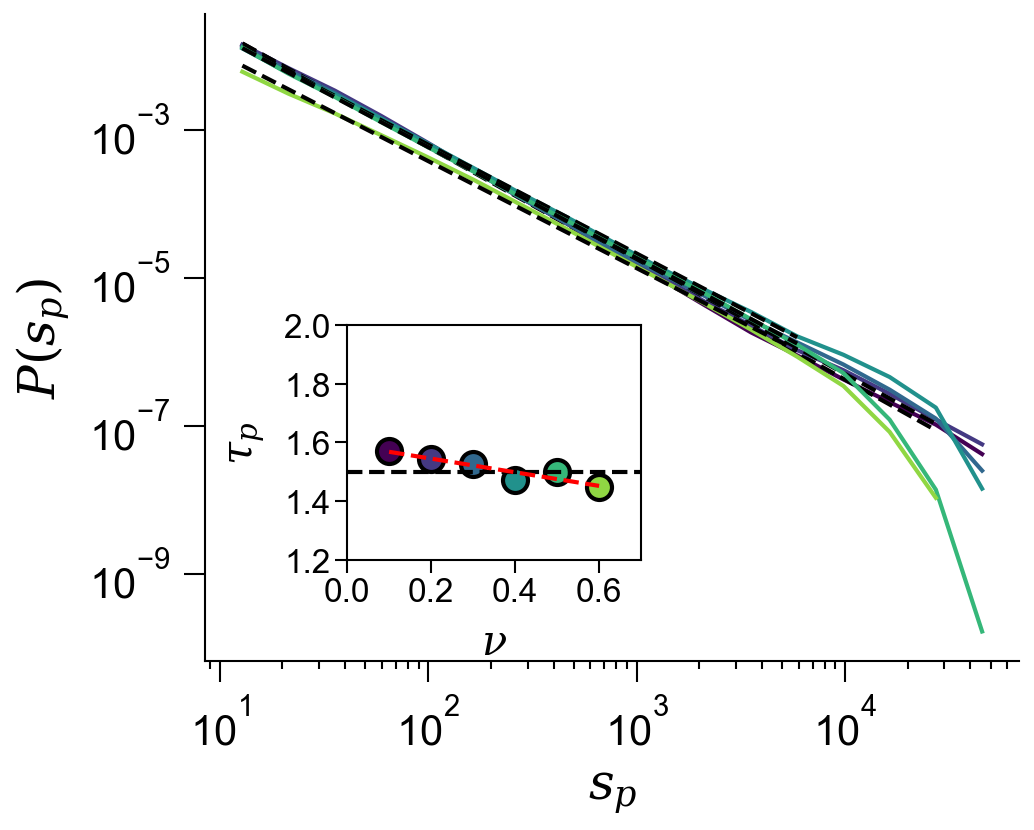

In [9]:

Tnu = np.array([read_parameters(folderpath)[2] for folderpath in folderpaths])
L1 = read_parameters(folderpaths[0])[0]
L2 = read_parameters(folderpaths[0])[1]
NCURVES = len(Tnu)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
log_bins = np.logspace(np.log(1), np.log(L1 * L2), nbins+1)


xmin = 10
xmax = [50000, 50000, 10000, 10000, 10000, 10000]
Tb = np.zeros(len(Tnu))
with plt.style.context(spstyle.get_style('thesis')):
    plt.rcParams['font.family'] = 'Arial' 
    fig, ax1 = plt.subplots(figsize=(3.5, 2.8))

    ax2 = fig.add_axes([0.26, 0.23, 0.28, 0.28])
    for j, (histo, x) in enumerate(zip(Thisto[:], Tnu[:])):


        mask = histo != 0
        fhist = histo[mask]
        fbins = log_bins[:-1][mask]
        idmin = np.argwhere(fbins>=xmin)[0][0]
        idmax = np.argwhere(fbins<=xmax[j])[-1][0]
        
        xfit = fbins[idmin: idmax]
        popt,pcov = curve_fit(powerlaw2, np.log(xfit), np.log(fhist[idmin:idmax]))
        a, b = popt
        yerr = np.sqrt(np.diag(pcov))[1]
        Tb[j] = -b
        yfit = np.exp(powerlaw2(np.log(xfit), *popt))
        
        ax1.plot(fbins[idmin:],fhist[idmin:], color = colors[j])
        ax1.plot(xfit, yfit, 'k--')
        ax2.errorbar(x, -np.round(b, 3), yerr = yerr, c = 'k')
        ax2.scatter(x, -np.round(b, 3), c = colors[j], zorder = 2)
        # ax2.errorbar(x, -np.round(result.x[1], 3), yerr = perr[1], fmt = 'o', color = colors[j])
    ax2.axhline(1.5, ls = '--', c = 'k')

    popt, pcov = curve_fit(linlaw, Tnu, Tb)
    print(popt)
    yerr = np.sqrt(np.diag(pcov))[0]
    print(yerr)
    yfit  = linlaw(Tnu, *popt)
    ax2.plot(Tnu, yfit, ls = '--', c = 'r')
    
    # ax1.axvline(L1 * L2, ls = '--', c = 'k')
    ax1.set_xlabel(r'$s_p$')
    ax1.set_ylabel(r'$P(s_p)$')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax2.set_xlabel(r"$\nu$", fontsize = 10)
    ax2.set_ylabel(r"$\tau_p$", fontsize = 10)
    ax2.set_ylim(1.2, 2)
    ax2.set_xlim(0, 0.7)
    ax2.set_xticks([0,0.2,0.4,0.6])
    ax2.set_yticks([1.2,1.4,1.6,1.8,2])
    ax2.tick_params(labelsize = 8, length = 3, pad = 1)
    ax2.spines['top'].set_visible(True)
    ax2.spines['right'].set_visible(True)
    

    # plt.tight_layout()
    # ax.legend(fontsize = 20)
    plt.savefig("P(s_p).pdf", bbox_inches = 'tight', dpi = 300)
    plt.show()

#   Openbc

In [12]:
#Pour faire l'analyse lancer les script Figure_otsu.py
data = np.load("Figure_otsu_open.npz", allow_pickle=True)
Thisto = data["Thisto"]

In [13]:

Tnu = np.array([read_parameters(folderpath)[2] for folderpath in folderpaths])
L1 = read_parameters(folderpaths[0])[0]
L2 = read_parameters(folderpaths[0])[1]
NCURVES = len(Tnu)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
log_bins = np.logspace(np.log(1), np.log(L1 * L2), nbins+1)

Tb = np.zeros(len(Tnu))
xmin = 10
xmax = [20000, 20000, 20000, 20000, 4000, 4000]
with plt.style.context(spstyle.get_style('thesis')):

    fig, ax1 = plt.subplots(figsize=(3.5, 2.8))

    ax2 = fig.add_axes([0.26, 0.235, 0.25, 0.25])
    for j, (histo, x) in enumerate(zip(Thisto[:], Tnu[:])):
        
        mask = histo != 0
        fhist = histo[mask]
        fbins = log_bins[:-1][mask]
        idmin = np.argwhere(fbins>=xmin)[0][0]
        idmax = np.argwhere(fbins<=xmax[j])[-1][0]
        
        xfit = fbins[idmin: idmax]
        popt,pcov = curve_fit(powerlaw2, np.log(xfit), np.log(fhist[idmin:idmax]))
        a, b = popt
        Tb[j] = -b
        yerr = np.sqrt(np.diag(pcov))[1]
        yfit = np.exp(powerlaw2(np.log(xfit), *popt))
        
        
        ax1.plot(fbins[idmin:],fhist[idmin:], color = colors[j])
        ax1.plot(xfit, yfit, 'k--')
        ax2.errorbar(x, -np.round(b, 3), yerr = yerr, c = 'k')
        ax2.scatter(x, -np.round(b, 3), c = colors[j], zorder = 2)
        leg2 = ax2.scatter(x, 2 - 1/(2*Tslope_pl[j]), c = color_list[2], label = "Theory")
        
        print(Tslope_pl[j])
        # ax2.errorbar(x, -np.round(result.x[1], 3), yerr = perr[1], fmt = 'o', color = colors[j])
    ax2.axhline(1.5, ls = '--', c = 'k')

    popt, pcov = curve_fit(linlaw, Tnu, Tb)
    print(popt)
    yerr = np.sqrt(np.diag(pcov))[0]
    print(yerr)
    yfit  = linlaw(Tnu, *popt)
    ax2.plot(Tnu, yfit, ls = '--', c = 'r')
    ax1.axvline(L1*L2, ls ='--', c ='grey')
    # ax1.axvline(L1 * L2, ls = '--', c = 'k')
    ax1.set_xlabel(r'$s_p$')
    ax1.set_ylabel(r'$P(s_p)$')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(5,1e5)
    ax1.set_ylim(1e-10,2e-2)
    ax2.set_xlabel(r"$\nu$", fontsize = 11)
    ax2.set_ylabel(r"$\tau_p$", fontsize = 11)
    ax2.set_ylim(1.2, 2)
    ax2.set_xlim(0, 0.7)
    ax2.set_xticks([0,0.2,0.4,0.6])
    ax2.set_yticks([1.2,1.4,1.6,1.8,2])
    ax2.tick_params(labelsize = 9, length = 3, pad = 1)
    ax2.spines['top'].set_visible(True)
    ax2.spines['right'].set_visible(True)
    
    ax1.legend(handles = [leg2], bbox_to_anchor = (0.9,1))
    

    # plt.tight_layout()
    # ax.legend(fontsize = 20)
    plt.savefig("P(s_p)_openbc.pdf", bbox_inches = 'tight', dpi = 300)
    plt.show()

/tmp/ipykernel_764817/635499305.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
/tmp/ipykernel_764817/635499305.py:35: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax2.scatter(x, -np.round(b, 3), c = colors[j], zorder = 2)


NameError: name 'Tslope_pl' is not defined

# Données brut

##  Open

In [17]:
data = np.load("Figure_otsu_open_brut.npz", allow_pickle=True)
Thisto = data["Thisto"]

data2 = np.load("Figure_otsu_brut.npz", allow_pickle=True)
Thisto2 = data2["Thisto"]

/tmp/ipykernel_764817/256783602.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
/tmp/ipykernel_764817/256783602.py:6: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors2 = [plt.cm.get_cmap('inferno')(i/NCURVES) for i in range(NCURVES)]
/tmp/ipykernel_764817/256783602.py:40: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB 

[-0.34311375  1.7344743 ]
0.06210934217238927
[-0.31296235  1.61872074]
0.05564255513856173


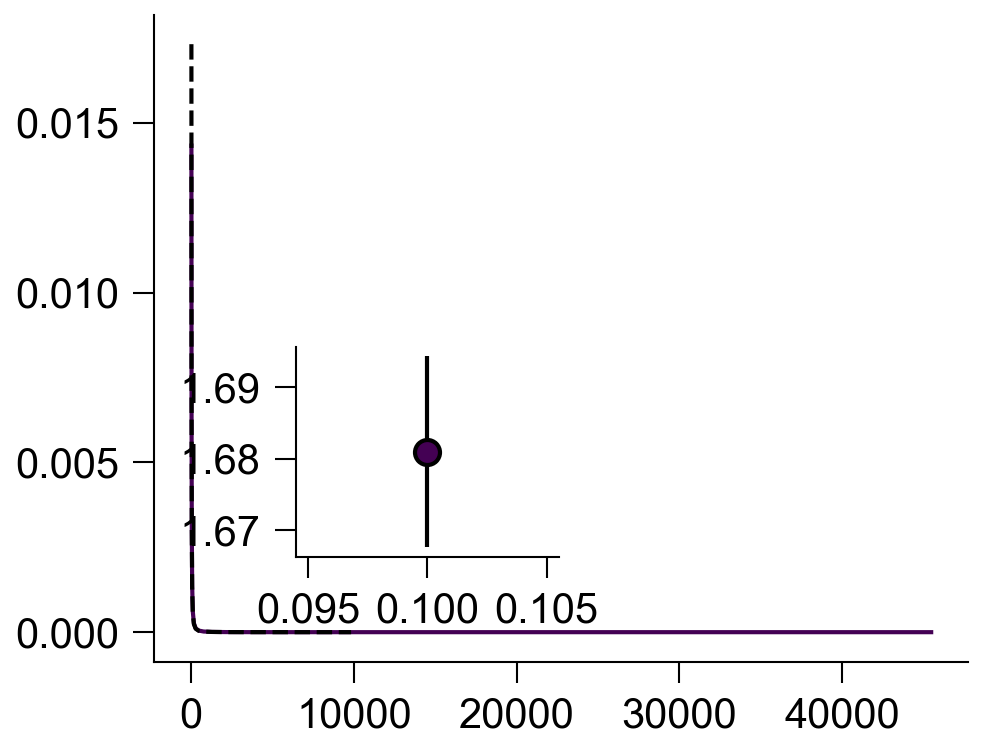

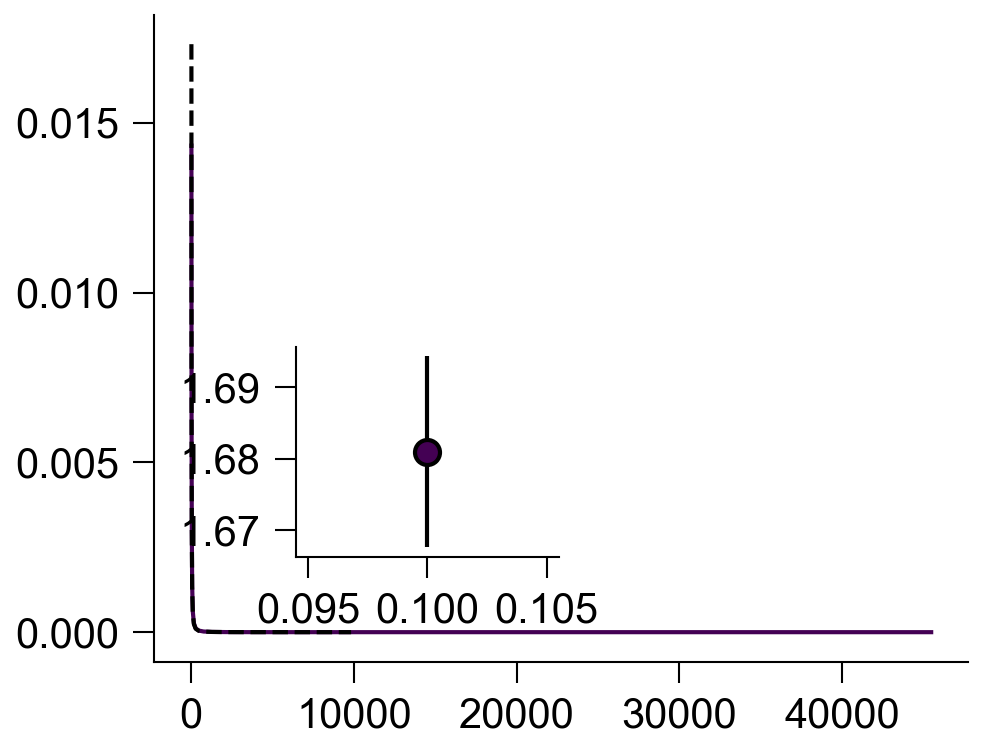

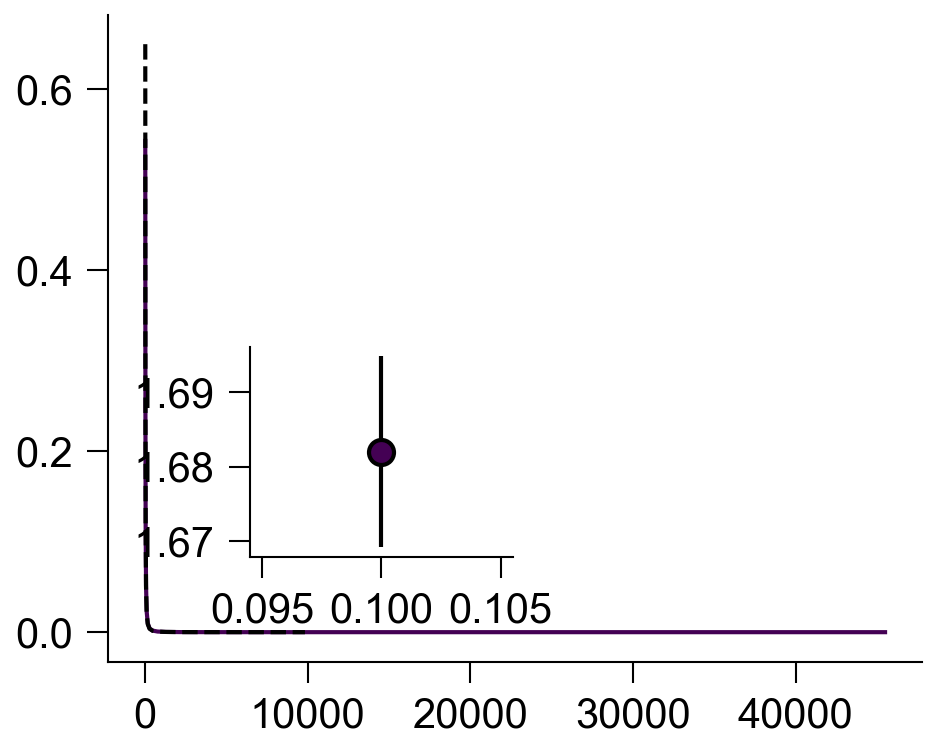

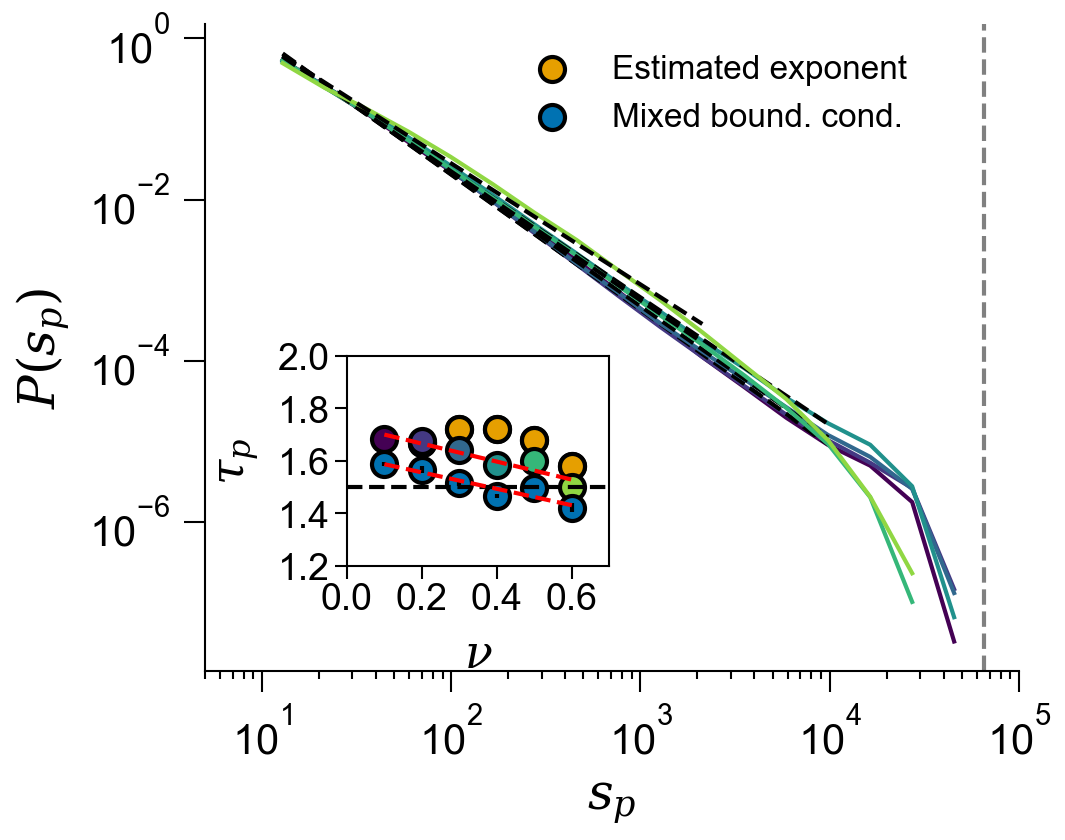

In [18]:

Tnu = np.array([read_parameters(folderpath)[2] for folderpath in folderpaths])
L1 = read_parameters(folderpaths[0])[0]
L2 = read_parameters(folderpaths[0])[1]
NCURVES = len(Tnu)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
colors2 = [plt.cm.get_cmap('inferno')(i/NCURVES) for i in range(NCURVES)]
log_bins = np.logspace(np.log(1), np.log(L1 * L2), nbins+1)
diff_bins = np.diff(log_bins)
Tb = np.zeros(len(Tnu))
xmin = 10
xmax = [20000, 20000, 20000, 20000, 4000, 4000]



with plt.style.context(spstyle.get_style('thesis')):

    fig, ax1 = plt.subplots(figsize=(3.5, 2.8))
    ax2 = fig.add_axes([0.26, 0.235, 0.25, 0.25])
    for j, (histo, x) in enumerate(zip(Thisto[:], Tnu[:])):
        
        histo = histo/diff_bins
        mask = histo != 0
        fhist = histo[mask]
        fbins = log_bins[:-1][mask]
        idmin = np.argwhere(fbins>=xmin)[0][0]
        idmax = np.argwhere(fbins<=xmax[j])[-1][0]
        nbpatch = np.sum(fhist[idmin:])
        
        xfit = fbins[idmin: idmax]
        popt,pcov = curve_fit(powerlaw2, np.log(xfit), np.log(fhist[idmin:idmax]/nbpatch))
        a, b = popt
        Tb[j] = -b
        yerr = np.sqrt(np.diag(pcov))[1]
        yfit = np.exp(powerlaw2(np.log(xfit), *popt))
        
        
        ax1.plot(fbins[idmin:],fhist[idmin:]/nbpatch, color = colors[j])
        ax1.plot(xfit, yfit, 'k--')
        ax2.errorbar(x, -np.round(b, 3), yerr = yerr, c = 'k')
        ax2.scatter(x, -np.round(b, 3), c = colors[j], zorder = 2)
        leg2 = ax2.scatter(x, 2 - 1/(2*Tslope_pl[j]), c = color_list[2], label = "Theory")
        
        # print(b)
        # print(Tslope_pl[j])
        # ax2.errorbar(x, -np.round(result.x[1], 3), yerr = perr[1], fmt = 'o', color = colors[j])
        
        
    popt, pcov = curve_fit(linlaw, Tnu, Tb)
    print(popt)
    yerr = np.sqrt(np.diag(pcov))[0]
    print(yerr)
    yfit  = linlaw(Tnu, *popt)
    ax2.plot(Tnu, yfit, ls = '--', c = 'r')
        
    for j, (histo, x) in enumerate(zip(Thisto2[:], Tnu[:])):
        
        histo = histo/diff_bins
        mask = histo != 0
        fhist = histo[mask]
        fbins = log_bins[:-1][mask]
        idmin = np.argwhere(fbins>=xmin)[0][0]
        idmax = np.argwhere(fbins<=xmax[j])[-1][0]
        nbpatch = np.sum(fhist[idmin:])
        
        xfit = fbins[idmin: idmax]
        popt,pcov = curve_fit(powerlaw2, np.log(xfit), np.log(fhist[idmin:idmax]/nbpatch))
        a, b = popt
        Tb[j] = -b
        yerr = np.sqrt(np.diag(pcov))[1]
        yfit = np.exp(powerlaw2(np.log(xfit), *popt))
        
        
        # ax1.plot(fbins[idmin:],fhist[idmin:]/nbpatch, color = colors[j])
        # ax1.plot(xfit, yfit, 'k--')
        if j == 0:
            leg3 = ax2.scatter(x, -np.round(b, 3), c = color_list[0], zorder = 2, label = 'Mixed bound. cond.')
        else:
            ax2.scatter(x, -np.round(b, 3), c = color_list[0], zorder = 2)
        ax2.errorbar(x, -np.round(b, 3), yerr = yerr, c = 'k')
        
        leg2 = ax2.scatter(x, 2 - 1/(2*Tslope_pl[j]), c = color_list[2], label = "Estimated exponent")
        
        # print(b)
        # print(Tslope_pl[j])
        # ax2.errorbar(x, -np.round(result.x[1], 3), yerr = perr[1], fmt = 'o', color = colors[j])
        
    ax2.axhline(1.5, ls = '--', c = 'k')

    popt, pcov = curve_fit(linlaw, Tnu, Tb)
    print(popt)
    yerr = np.sqrt(np.diag(pcov))[0]
    print(yerr)
    yfit  = linlaw(Tnu, *popt)
    ax2.plot(Tnu, yfit, ls = '--', c = 'r')
    
    ax1.axvline(L1*L2, ls ='--', c ='grey')
    # ax1.axvline(L1 * L2, ls = '--', c = 'k')
    ax1.set_xlabel(r'$s_p$')
    ax1.set_ylabel(r'$P(s_p)$')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(5,1e5)
    # ax1.set_ylim(1e-10,2e-2)
    ax2.set_xlabel(r"$\nu$", fontsize = 11)
    ax2.set_ylabel(r"$\tau_p$", fontsize = 11)
    ax2.set_ylim(1.2, 2)
    ax2.set_xlim(0, 0.7)
    ax2.set_xticks([0,0.2,0.4,0.6])
    ax2.set_yticks([1.2,1.4,1.6,1.8,2])
    ax2.tick_params(labelsize = 9, length = 3, pad = 1)
    ax2.spines['top'].set_visible(True)
    ax2.spines['right'].set_visible(True)
    
    ax1.legend(handles = [leg2, leg3], bbox_to_anchor = (0.9,1))
    

    # plt.tight_layout()
    # ax.legend(fontsize = 20)
    plt.savefig("P(s_p)_openbc.pdf", bbox_inches = 'tight', dpi = 300)
    plt.show()

##  Periodic

In [18]:
data = np.load("Figure_otsu_brut.npz", allow_pickle=True)
Thisto = data["Thisto"]

/tmp/ipykernel_306335/2954675247.py:5: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed two minor releases later. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap(obj)`` instead.
  colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
/tmp/ipykernel_306335/2954675247.py:38: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax2.scatter(x, -np.round(b, 3), c = colors[j], zorder = 2)
/tmp/ipykernel_306335/2954675247.py:39: RuntimeWarning: divide by zero encountered in scalar divide
  leg2 = ax2.scatter(x, 2 - 1/(2*Tslope_pl[j]), c = color_list[2], label = "Theory")


[-0.31296235  1.61872074]
0.05564255513856173


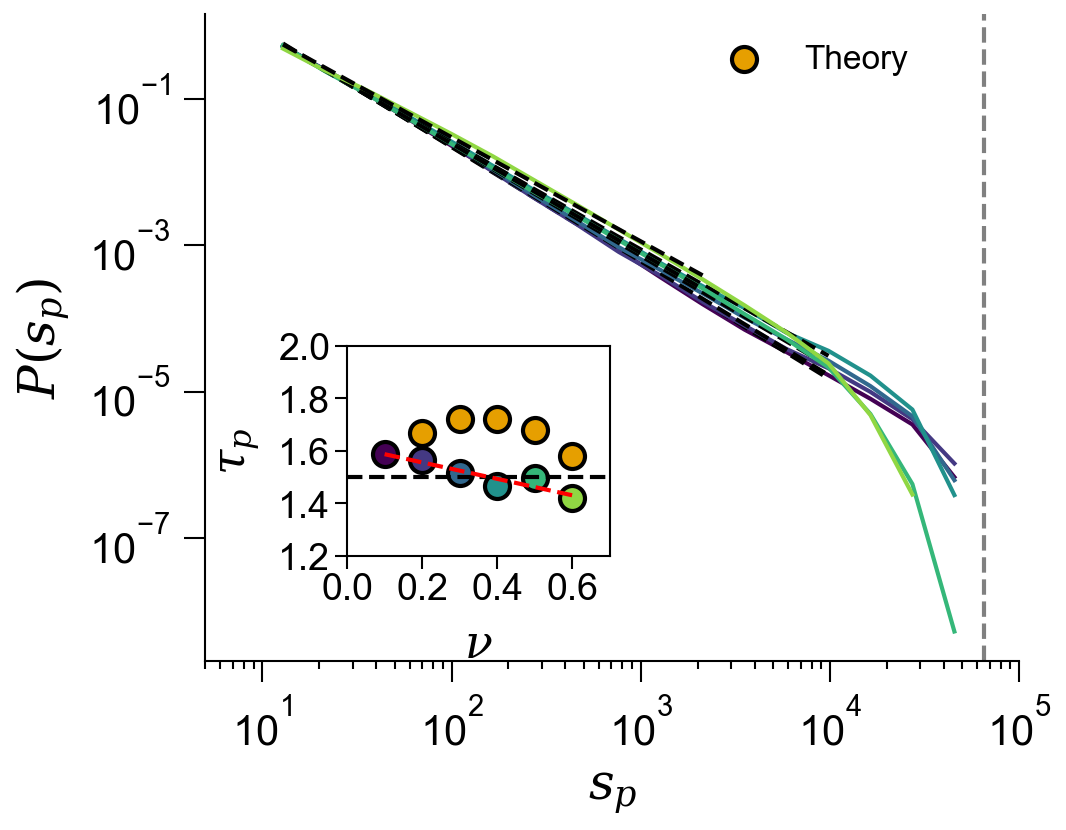

In [19]:

Tnu = np.array([read_parameters(folderpath)[2] for folderpath in folderpaths])
L1 = read_parameters(folderpaths[0])[0]
L2 = read_parameters(folderpaths[0])[1]
NCURVES = len(Tnu)
colors = [plt.cm.get_cmap('viridis')(i/NCURVES) for i in range(NCURVES)]
log_bins = np.logspace(np.log(1), np.log(L1 * L2), nbins+1)
diff_bins = np.diff(log_bins)
Tb = np.zeros(len(Tnu))
xmin = 10
xmax = [20000, 20000, 20000, 20000, 4000, 4000]



with plt.style.context(spstyle.get_style('thesis')):

    fig, ax1 = plt.subplots(figsize=(3.5, 2.8))
    ax2 = fig.add_axes([0.26, 0.235, 0.25, 0.25])
    for j, (histo, x) in enumerate(zip(Thisto[:], Tnu[:])):
        
        histo = histo/diff_bins
        mask = histo != 0
        fhist = histo[mask]
        fbins = log_bins[:-1][mask]
        idmin = np.argwhere(fbins>=xmin)[0][0]
        idmax = np.argwhere(fbins<=xmax[j])[-1][0]
        nbpatch = np.sum(fhist[idmin:])
        xfit = fbins[idmin: idmax]
        popt,pcov = curve_fit(powerlaw2, np.log(xfit), np.log(fhist[idmin:idmax]/nbpatch))
        a, b = popt
        Tb[j] = -b
        yerr = np.sqrt(np.diag(pcov))[1]
        yfit = np.exp(powerlaw2(np.log(xfit), *popt))
        
        
        ax1.plot(fbins[idmin:],fhist[idmin:]/nbpatch, color = colors[j])
        ax1.plot(xfit, yfit, 'k--')
        ax2.errorbar(x, -np.round(b, 3), yerr = yerr, c = 'k')
        ax2.scatter(x, -np.round(b, 3), c = colors[j], zorder = 2)
        leg2 = ax2.scatter(x, 2 - 1/(2*Tslope_pl[j]), c = color_list[2], label = "Theory")
        
        # print(b)
        # print(Tslope_pl[j])
        # ax2.errorbar(x, -np.round(result.x[1], 3), yerr = perr[1], fmt = 'o', color = colors[j])
    ax2.axhline(1.5, ls = '--', c = 'k')

    popt, pcov = curve_fit(linlaw, Tnu, Tb)
    print(popt)
    yerr = np.sqrt(np.diag(pcov))[0]
    print(yerr)
    yfit  = linlaw(Tnu, *popt)
    ax2.plot(Tnu, yfit, ls = '--', c = 'r')
    ax1.axvline(L1*L2, ls ='--', c ='grey')
    # ax1.axvline(L1 * L2, ls = '--', c = 'k')
    ax1.set_xlabel(r'$s_p$')
    ax1.set_ylabel(r'$P(s_p)$')
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlim(5,1e5)
    # ax1.set_ylim(1e-10,2e-2)
    ax2.set_xlabel(r"$\nu$", fontsize = 11)
    ax2.set_ylabel(r"$\tau_p$", fontsize = 11)
    ax2.set_ylim(1.2, 2)
    ax2.set_xlim(0, 0.7)
    ax2.set_xticks([0,0.2,0.4,0.6])
    ax2.set_yticks([1.2,1.4,1.6,1.8,2])
    ax2.tick_params(labelsize = 9, length = 3, pad = 1)
    ax2.spines['top'].set_visible(True)
    ax2.spines['right'].set_visible(True)
    
    ax1.legend(handles = [leg2], bbox_to_anchor = (0.9,1))
    

    # plt.tight_layout()
    # ax.legend(fontsize = 20)
    plt.savefig("P(s_p)_openbc.pdf", bbox_inches = 'tight', dpi = 300)
    plt.show()